[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nekrut/bda/blob/main/lectures/lecture4.ipynb)

# Lecture 4: Lists and Dictionaries

[![XKCD 2483](https://imgs.xkcd.com/comics/seven.png)](https://xkcd.com/2483)

**Preclass prep:** Chapters [5](https://greenteapress.com/thinkpython2/html/thinkpython2009.html) and [7](https://greenteapress.com/thinkpython2/html/thinkpython2011.html) from "Think Python"

::: {.callout-tip}
## Attribution
This material uses examples from notebooks developed by [Ben Langmead](https://langmead-lab.org/teaching-materials/)
:::

## Prep

1. Start [JupyterLab](https://mybinder.org/v2/gh/jupyterlab/jupyterlab-demo/try.jupyter.org?urlpath=lab)
2. Within JupyterLab start a new Python3 notebook
3. Open [this page](http://cs1110.cs.cornell.edu/tutor/#mode=edit) in a new browser tab

# Lists: Dynamic programming in sequence alignment

## Dynamic programming matrix as a 2D list

An excellent way to illustrate the utility of lists is to implement a dynamic programming algorithm for sequence alignment. Suppose we have two sequences that deliberately have different lengths:

$$
\texttt{G C T A T A C}
$$

and 

$$
\texttt{G C G T A T G C}
$$

Let's represent them as the following matrix where the first character $\epsilon$ represents an empty string:

$$
\begin{array}{ c | c | c | c | c | c | c}
& \epsilon & G & C & T & A & T & A & C\\
\hline
\epsilon \\
\hline
G\\
\hline
 C\\
 \hline
G\\
\hline
T\\
\hline
A\\
 \hline
T\\
\hline
G\\
\hline
C
\end{array}
\\
\textbf{Note}: sequence\ \texttt{X}\ is\ vertical\ and\ sequence\ \texttt{Y}\ is\ horizontal.
$$

In this matrix, the cells are addressed as shown below. They filled in using the following logic:

$$
D[i,j] = min\begin{cases} 
          \color{green}{D[i-1,j] + 1} & \\
          \color{blue}{D[i,j-1] + 1} & \\
          \color{red}{D[i-1,j-1] + \delta(x[i-1],y[j-1])}
             \end{cases}
$$

where $\color{green}{green}$ is *upper* cell, $\color{blue}{blue}$ is *left* cell, and $\color{red}{red}$ is *upper-left* cell.

## Initializing the matrix

Let's initialize the first column and first row of the matrix. Because the distance between a string and an empty string is equal to the length of the string (e.g., a distance between, say, string $\texttt{TCG}$ and an empty string is 3) this resulting matrix will look like this:

$$
\begin{array}{ c | c | c | c | c | c | c}
& \epsilon & G & C & T & A & T & A & C\\
            \hline
          \epsilon & 0 & 1 & 2 & 3 & 4 & 5 & 6 & 7\\
          \hline
          G & 1\\
          \hline
          C & 2\\
          \hline
          G & 3\\
          \hline
          T & 4\\
          \hline
          A & 5\\
          \hline
          T & 6\\
          \hline
          G & 7\\
          \hline
          C & 8
\end{array}
\\
\textbf{Note}: sequence\ \texttt{X}\ is\ vertical\ and\ sequence\ \texttt{Y}\ is\ horizontal.
$$

This can be achieved with the following code:

In [1]:
import numpy as np

x = 'GCGTATGC'
y = 'GCTATAC'

D = np.zeros((len(x)+1, len(y)+1), dtype=int)
D[0, 1:] = range(1, len(y)+1)
D[1:, 0] = range(1, len(x)+1)

print(D)

[[0 1 2 3 4 5 6 7]
 [1 0 0 0 0 0 0 0]
 [2 0 0 0 0 0 0 0]
 [3 0 0 0 0 0 0 0]
 [4 0 0 0 0 0 0 0]
 [5 0 0 0 0 0 0 0]
 [6 0 0 0 0 0 0 0]
 [7 0 0 0 0 0 0 0]
 [8 0 0 0 0 0 0 0]]


## Filling the matrix

Now we can fill the entire matrix by using two nested loops: one iterating over $i$ coordinate (sequence $x$) and the other iterating over $j$ coordinate (sequence $y$):

In [2]:
for i in range(1, len(x)+1):
    for j in range(1, len(y)+1):
        delta = 1 if x[i-1] != y[j-1] else 0
        D[i, j] = min(D[i-1, j-1]+delta, D[i-1, j]+1, D[i, j-1]+1)

print(D)

[[0 1 2 3 4 5 6 7]
 [1 0 1 2 3 4 5 6]
 [2 1 0 1 2 3 4 5]
 [3 2 1 1 2 3 4 5]
 [4 3 2 1 2 2 3 4]
 [5 4 3 2 1 2 2 3]
 [6 5 4 3 2 1 2 3]
 [7 6 5 4 3 2 2 3]
 [8 7 6 5 4 3 3 2]]


The lower rightmost cell is special. It contains the value for the edit distance between the two strings.

The following Python script implements this idea as a function:

In [3]:
import numpy as np

def edDistDp(x, y):
    """ Calculate edit distance between sequences x and y using
        matrix dynamic programming.  Return matrix and distance. """
    D = np.zeros((len(x)+1, len(y)+1), dtype=int)
    D[0, 1:] = range(1, len(y)+1)
    D[1:, 0] = range(1, len(x)+1)
    for i in range(1, len(x)+1):
        for j in range(1, len(y)+1):
            delta = 1 if x[i-1] != y[j-1] else 0
            D[i, j] = min(D[i-1, j-1]+delta, D[i-1, j]+1, D[i, j-1]+1)
    return D, D[len(x), len(y)]

In [4]:
# Test the function
D, distance = edDistDp('GCGTATGC', 'GCTATAC')
print(f"Edit distance: {distance}")
print(D)

Edit distance: 2
[[0 1 2 3 4 5 6 7]
 [1 0 1 2 3 4 5 6]
 [2 1 0 1 2 3 4 5]
 [3 2 1 1 2 3 4 5]
 [4 3 2 1 2 2 3 4]
 [5 4 3 2 1 2 2 3]
 [6 5 4 3 2 1 2 3]
 [7 6 5 4 3 2 2 3]
 [8 7 6 5 4 3 3 2]]


A graphical representation of the matrix between `GCGTATGCACGC` and `GCTATGCCACGC` looks like this:

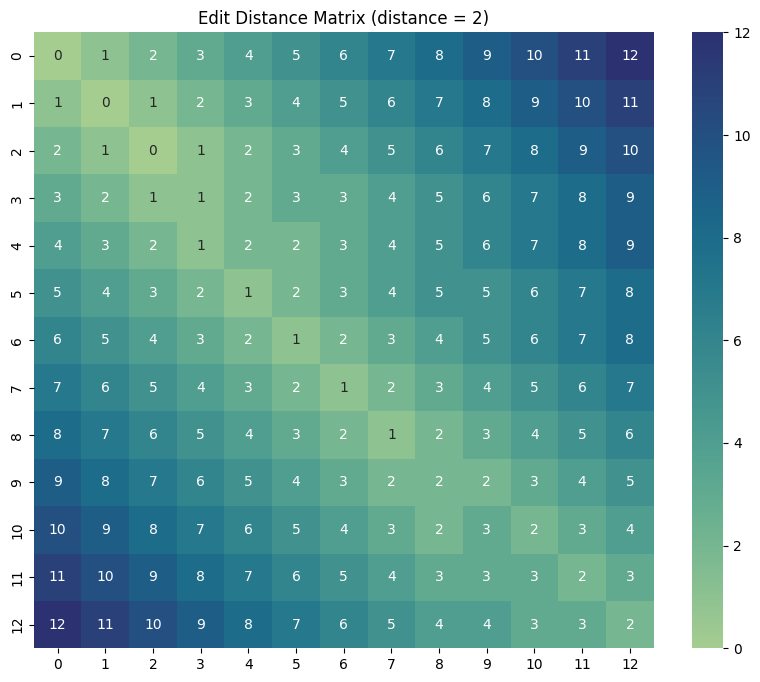

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

D, distance = edDistDp('GCGTATGCACGC', 'GCTATGCCACGC')

plt.figure(figsize=(10, 8))
sns.heatmap(D, annot=True, cmap="crest", fmt='d')
plt.title(f'Edit Distance Matrix (distance = {distance})')
plt.show()

---

# Dictionaries: Translating sequences

Perhaps the best way to demonstrate the utility of dictionaries is by using DNA-to-Protein translation as an example.

## Using dictionaries to translate DNA

The genetic code maps codons (triplets of nucleotides) to amino acids. We define it once as a constant that can be reused across all our translation functions:

In [6]:
# Define the genetic code as a constant (codon -> amino acid)
GENETIC_CODE = {
    'ATA':'I', 'ATC':'I', 'ATT':'I', 'ATG':'M',
    'ACA':'T', 'ACC':'T', 'ACG':'T', 'ACT':'T',
    'AAC':'N', 'AAT':'N', 'AAA':'K', 'AAG':'K',
    'AGC':'S', 'AGT':'S', 'AGA':'R', 'AGG':'R',                
    'CTA':'L', 'CTC':'L', 'CTG':'L', 'CTT':'L',
    'CCA':'P', 'CCC':'P', 'CCG':'P', 'CCT':'P',
    'CAC':'H', 'CAT':'H', 'CAA':'Q', 'CAG':'Q',
    'CGA':'R', 'CGC':'R', 'CGG':'R', 'CGT':'R',
    'GTA':'V', 'GTC':'V', 'GTG':'V', 'GTT':'V',
    'GCA':'A', 'GCC':'A', 'GCG':'A', 'GCT':'A',
    'GAC':'D', 'GAT':'D', 'GAA':'E', 'GAG':'E',
    'GGA':'G', 'GGC':'G', 'GGG':'G', 'GGT':'G',
    'TCA':'S', 'TCC':'S', 'TCG':'S', 'TCT':'S',
    'TTC':'F', 'TTT':'F', 'TTA':'L', 'TTG':'L',
    'TAC':'Y', 'TAT':'Y', 'TAA':'_', 'TAG':'_',
    'TGC':'C', 'TGT':'C', 'TGA':'_', 'TGG':'W',
}

Let's generate a random DNA sequence:

In [7]:
import random
seq = "".join([random.choice('atcg') for x in range(100)])
seq

'cctcatcttccatacaactgtcacagtgttgctcaaagcggcgaaaaagtgtgggagttttgttaggaggtgtttcgtatacaggaatatattcgctatt'

To translate this sequence we write a code that uses a `for` loop that iterates over the DNA sequence in steps of 3, creating a codon at each iteration. If the codon is less than 3 letters long, the loop is broken. The resulting amino acid is then added to the `translation` string:

In [8]:
translation = ""
for i in range(0, len(seq), 3):
    codon = seq[i:i+3].upper()
    if len(codon) < 3: break
    if codon in GENETIC_CODE:
        translation += GENETIC_CODE[codon]
    else:
        translation += "X"

print("Translation:", translation)

Translation: PHLPYNCHSVAQSGEKVWEFC_EVFRIQEYIRY


Note that the code uses the `upper()` method to ensure the codon is in uppercase since the table dictionary is case-sensitive. Additionally, the code checks if the codon is in the table dictionary and if not, it adds the letter "X" to the translation. This is a common way to represent unknown or stop codons in a protein sequence.

Now we define a function that would perform translation so that we can reuse it later:

In [9]:
def translate(seq):
    """Translate a DNA sequence to protein using the standard genetic code."""
    translation = ''
    for i in range(0, len(seq), 3):
        codon = seq[i:i+3].upper()
        if len(codon) < 3: break
        if codon in GENETIC_CODE:
            translation += GENETIC_CODE[codon]
        else:
            translation += "X"
    return translation

In [10]:
translate(seq)

'PHLPYNCHSVAQSGEKVWEFC_EVFRIQEYIRY'

## Expanding to multiple phases (frames)

We can further modify the function by adding a `phase` parameter that would allow translating in any of the three phases:

In [11]:
def translate_phase(seq, phase):
    """Translate a DNA sequence to protein starting at a given phase (0, 1, or 2)."""
    assert 0 <= phase <= 2, f"Phase must be 0, 1, or 2, got {phase}"
    translation = ''
    for i in range(phase, len(seq), 3):
        codon = seq[i:i+3].upper()
        if len(codon) < 3: break
        if codon in GENETIC_CODE:
            translation += GENETIC_CODE[codon]
        else:
            translation += "X"
    return translation

In [12]:
translate_phase(seq, 0)

'PHLPYNCHSVAQSGEKVWEFC_EVFRIQEYIRY'

In [13]:
translate_phase(seq, 1)

'LIFHTTVTVLLKAAKKCGSFVRRCFVYRNIFAI'

In [14]:
translate_phase(seq, 2)

'SSSIQLSQCCSKRRKSVGVLLGGVSYTGIYSL'

To translate in all six reading frames (three of the "+" strand and three of the "-" strand) we need to be able to create a reverse complement of the sequence. Let's write a simple function for that.

The cell below implements a function `revcomp` that takes a DNA sequence as input and returns its reverse complement. It works by first reversing the sequence using the slice notation `seq[::-1]`, which returns the sequence in reverse order. Then, the `translate` method is used with the `str.maketrans` function to replace each occurrence of 'a', 't', 'g', 'c', 'A', 'T', 'G', and 'C' in the reversed sequence with 't', 'a', 'c', 'g', 'T', 'A', 'C', and 'G', respectively:

In [15]:
import string

# Pre-compute the complement translation table for efficiency
_COMPLEMENT_TABLE = str.maketrans('atgcATGC', 'tacgTACG')

def revcomp(seq):
    """Return the reverse complement of a DNA sequence."""
    return seq[::-1].translate(_COMPLEMENT_TABLE)

Now let's use this function to create translation in all six reading frames. The cell below uses a `for` loop that iterates over the range `(0, 3)`, representing the different phases (or starting positions) of the translation. At each iteration, the `translate_phase` function is called with the DNA sequence and the current phase, and the resulting protein sequence is appended to the `translations` list along with the `phase` and the `strand` orientation (+ or -):

In [16]:
translations = []

for i in range(0,3):
    translations.append((translate_phase(seq,i),str(i),'+'))
    translations.append((translate_phase(revcomp(seq),i),str(i),'-'))

translations

[('PHLPYNCHSVAQSGEKVWEFC_EVFRIQEYIRY', '0', '+'),
 ('NSEYIPVYETPPNKTPTLFRRFEQHCDSCMEDE', '0', '-'),
 ('LIFHTTVTVLLKAAKKCGSFVRRCFVYRNIFAI', '1', '+'),
 ('IANIFLYTKHLLTKLPHFFAALSNTVTVVWKMR', '1', '-'),
 ('SSSIQLSQCCSKRRKSVGVLLGGVSYTGIYSL', '2', '+'),
 ('_RIYSCIRNTS_QNSHTFSPL_ATL_QLYGR_', '2', '-')]

## Finding coordinates of continuous translations

The translation we've generated above contains stops (e.g., `_` symbols). The actual biologically relevant protein sequences are between stops.
We now need to split translation strings into meaningful peptide sequences and compute their coordinates. Let's begin by splitting a string on `_` and computing the start and end positions of each peptide:

In [17]:
string = "aadsds_dsds_dsds"

split_indices = []
for i, char in enumerate(string):
    if char == "_":
        split_indices.append(i)
print(split_indices)

[6, 11]


The code above generates a list of split indices for a string. The list contains the indices of the characters in the string that match a specified character (in this case, the underscore `_` character).

But we actually need coordinates of peptides bound by `_` characters. To get to this let's first modify `split_indices` by adding the beginning and end:

In [18]:
string = "aadsds_dsds_dsds"

split_indices = []
for i, char in enumerate(string):
    if char == "_":
        split_indices.append(i)
        
split_indices.insert(0, -1)
split_indices.append(len(string))
print(split_indices)

[-1, 6, 11, 16]


Now, let's convert these to ranges and also stick the peptide sequence in:

In [19]:
string = "aadsds_dsds_dsds"

split_indices = []
for i, char in enumerate(string):
    if char == "_":
        split_indices.append(i)
        
split_indices.insert(0, -1)
split_indices.append(len(string))

orfs = string.split('_')

parts = []
for i in range(len(split_indices)-1):
    parts.append((orfs[i], split_indices[i]+1, split_indices[i+1]))

print(parts)

[('aadsds', 0, 6), ('dsds', 7, 11), ('dsds', 12, 16)]


Now let's convert this to function:

In [20]:
def extract_coords(translation):
    split_indices = []
    for i, char in enumerate(translation):
        if char == "_":
            split_indices.append(i)
        
    split_indices.insert(0, -1)
    split_indices.append(len(translation))

    parts = []
    for i in range(len(split_indices)-1):
        parts.append((translation.split('_')[i], split_indices[i] + 1, split_indices[i + 1]))

    return(parts)

In [21]:
extract_coords(string)

[('aadsds', 0, 6), ('dsds', 7, 11), ('dsds', 12, 16)]

And specify the right parameters to make it truly generic:

In [22]:
def extract_coords_with_annotation(separator, translation, phase, strand):
    split_indices = []
    for i, char in enumerate(translation):
        if char == separator:
            split_indices.append(i)
        
    split_indices.insert(0, -1)
    split_indices.append(len(translation))

    parts = []
    for i in range(len(split_indices)-1):
        parts.append((translation.split(separator)[i], phase, strand, split_indices[i]+1, split_indices[i+1]))

    return(parts)

In [23]:
extract_coords_with_annotation('_', string, '0', '+')

[('aadsds', '0', '+', 0, 6),
 ('dsds', '0', '+', 7, 11),
 ('dsds', '0', '+', 12, 16)]

## Analyzing all translations of a given sequence

We begin by parsing the `translations` list we defined above:

In [24]:
all_translations = []
for item in translations:
    all_translations.append(extract_coords_with_annotation('_', item[0], item[1], item[2]))

all_translations

[[('PHLPYNCHSVAQSGEKVWEFC', '0', '+', 0, 21),
  ('EVFRIQEYIRY', '0', '+', 22, 33)],
 [('NSEYIPVYETPPNKTPTLFRRFEQHCDSCMEDE', '0', '-', 0, 33)],
 [('LIFHTTVTVLLKAAKKCGSFVRRCFVYRNIFAI', '1', '+', 0, 33)],
 [('IANIFLYTKHLLTKLPHFFAALSNTVTVVWKMR', '1', '-', 0, 33)],
 [('SSSIQLSQCCSKRRKSVGVLLGGVSYTGIYSL', '2', '+', 0, 32)],
 [('', '2', '-', 0, 0),
  ('RIYSCIRNTS', '2', '-', 1, 11),
  ('QNSHTFSPL', '2', '-', 12, 21),
  ('ATL', '2', '-', 22, 25),
  ('QLYGR', '2', '-', 26, 31),
  ('', '2', '-', 32, 32)]]

Now the problem with this list is that it is nested. However, we need to make it flat:

In [25]:
flat_list = []
for sublist in all_translations:
    for item in sublist:
        flat_list.append(item)

flat_list

[('PHLPYNCHSVAQSGEKVWEFC', '0', '+', 0, 21),
 ('EVFRIQEYIRY', '0', '+', 22, 33),
 ('NSEYIPVYETPPNKTPTLFRRFEQHCDSCMEDE', '0', '-', 0, 33),
 ('LIFHTTVTVLLKAAKKCGSFVRRCFVYRNIFAI', '1', '+', 0, 33),
 ('IANIFLYTKHLLTKLPHFFAALSNTVTVVWKMR', '1', '-', 0, 33),
 ('SSSIQLSQCCSKRRKSVGVLLGGVSYTGIYSL', '2', '+', 0, 32),
 ('', '2', '-', 0, 0),
 ('RIYSCIRNTS', '2', '-', 1, 11),
 ('QNSHTFSPL', '2', '-', 12, 21),
 ('ATL', '2', '-', 22, 25),
 ('QLYGR', '2', '-', 26, 31),
 ('', '2', '-', 32, 32)]

Now we can load the list into `Pandas` and plot away:

In [26]:
import pandas as pd
df = pd.DataFrame(flat_list, columns=['aa', 'frame', 'strand', 'start', 'end'])
df

,aa,frame,strand,start,end
0,PHLPYNCHSVAQSGEKVWEFC,0,+,0,21
1,EVFRIQEYIRY,0,+,22,33
2,NSEYIPVYETPPNKTPTLFRRFEQHCDSCMEDE,0,-,0,33
3,LIFHTTVTVLLKAAKKCGSFVRRCFVYRNIFAI,1,+,0,33
4,IANIFLYTKHLLTKLPHFFAALSNTVTVVWKMR,1,-,0,33
5,SSSIQLSQCCSKRRKSVGVLLGGVSYTGIYSL,2,+,0,32
6,,2,-,0,0
7,RIYSCIRNTS,2,-,1,11
8,QNSHTFSPL,2,-,12,21
9,ATL,2,-,22,25


Now let's plot it:

In [27]:
import altair as alt

plus = alt.Chart(df[df['strand']=='+']).mark_rect().encode(
    x = alt.X('start:Q'),
    x2 = alt.X2('end:Q'),
    y = alt.Y('frame:N'),
    color='frame',
    tooltip='aa:N'
).properties(
    width=600,
    height=100,
    title='Plus strand'
)

minus = alt.Chart(df[df['strand']=='-']).mark_rect().encode(
    x = alt.X('start:Q', sort=alt.EncodingSortField('start:Q', order='descending')),
    x2 = alt.X2('end:Q'),
    y = alt.Y('frame:N'),
    color='frame',
    tooltip='aa:N'
).properties(
    width=600,
    height=100,
    title='Minus strand'
)

plus & minus

alt.VConcatChart(...)